In [62]:
# Анализ продаж интернет-магазина

## Описание проекта

"""
В проекте проводится исследовательский анализ данных о продажах интернет-магазина. 
Датасет содержит информацию о заказах, клиентах, товарах, категориях, регионах, способах доставки и сумме продаж.
Цель проекта - изучить структуру продаж интернет-магазина, определить наиболее прибыльные категории товаров, 
проанализировать динамику продаж и выявить ключевые закономерности в данных.
"""

'\nВ проекте проводится исследовательский анализ данных о продажах интернет-магазина. \nДатасет содержит информацию о заказах, клиентах, товарах, категориях, регионах, способах доставки и сумме продаж.\nЦель проекта - изучить структуру продаж интернет-магазина, определить наиболее прибыльные категории товаров, \nпроанализировать динамику продаж и выявить ключевые закономерности в данных.\n'

In [ ]:
## Вопросы исследования
"""
1. Какова общая сумма продаж?
2. Сколько уникальных заказов и клиентов содержится в данных?
3. Как меняются продажи по годам и месяцам?
4. Какие категории и подкатегории товаров приносят больше всего продаж?
5. Какие регионы и штаты дают наибольший вклад в продажи?
6. Как распределяются продажи по сегментам клиентов?
7. Какие способы доставки используются чаще всего?
8. Какие товары входят в топ по сумме продаж?
9. Есть ли в данных пропуски, дубликаты или аномалии?
"""

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os

os.makedirs("images", exist_ok=True)

In [8]:
#Загрузка данных
df = pd.read_csv("C:/Users/Artem/Desktop/project/data/train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
#первичный обзрп данных

In [9]:
df.shape

(9800, 18)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [12]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [13]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
#На этапе первичного обзора были изучены размер таблицы, названия столбцов, типы данных и основные 
#статистические характеристики числовых признаков.

In [14]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='object')

In [ ]:
#Названия столбцов были приведены к единому стилю: нижний регистр, пробелы заменены на подчёркивания. 
#Это делает дальнейшую работу с данными удобнее.

In [15]:
df.isna().sum().sort_values(ascending=False)

postal_code      11
row_id            0
order_id          0
product_name      0
sub_category      0
category          0
product_id        0
region            0
state             0
city              0
country           0
segment           0
customer_name     0
customer_id       0
ship_mode         0
ship_date         0
order_date        0
sales             0
dtype: int64

In [ ]:
#В данных обнаружены пропуски в столбце `postal_code`. 
#Так как почтовый индекс не используется в основном анализе продаж, эти пропуски не влияют на расчёт ключевых метрик. 
#Удалять строки из-за этих пропусков не требуется.

In [16]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Дубликатов не было обнаружено

In [19]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], dayfirst=True)

df[["order_date", "ship_date"]].head()

,order_date,ship_date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [ ]:
#Столбцы `order_date` и `ship_date` были приведены к формату datetime. 
#Это позволит анализировать продажи по годам и месяцам, а также рассчитывать срок доставки.

In [20]:
#Создание новых признаков
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_year_month"] = df["order_date"].dt.to_period("M")
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days

In [ ]:
#Эти признаки понадобятся для анализа динамики продаж и способов доставки.

In [21]:
#Расчет основных метрик
total_sales = df["sales"].sum()
orders_count = df["order_id"].nunique()
customers_count = df["customer_id"].nunique()
products_count = df["product_id"].nunique()
avg_order_value = df.groupby("order_id")["sales"].sum().mean()

print(f"Общая сумма продаж: {total_sales:,.2f}")
print(f"Количество заказов: {orders_count}")
print(f"Количество клиентов: {customers_count}")
print(f"Количество товаров: {products_count}")
print(f"Средний чек: {avg_order_value:,.2f}")

Общая сумма продаж: 2,261,536.78
Количество заказов: 4922
Количество клиентов: 793
Количество товаров: 1861
Средний чек: 459.48


In [ ]:
#Были рассчитаны ключевые показатели: общая сумма продаж, количество уникальных заказов, количество клиентов, количество товаров и средний чек. 
#Эти метрики позволяют оценить общий масштаб продаж в датасете.

In [22]:
#Анализ продаж по годам
sales_by_year = df.groupby("order_year")["sales"].sum()

sales_by_year

order_year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: sales, dtype: float64

In [ ]:
#Анализ продаж по годам позволяет увидеть, как менялся общий объём продаж в разные периоды. 
#По графику можно определить, росли ли продажи от года к году или оставались примерно на одном уровне.

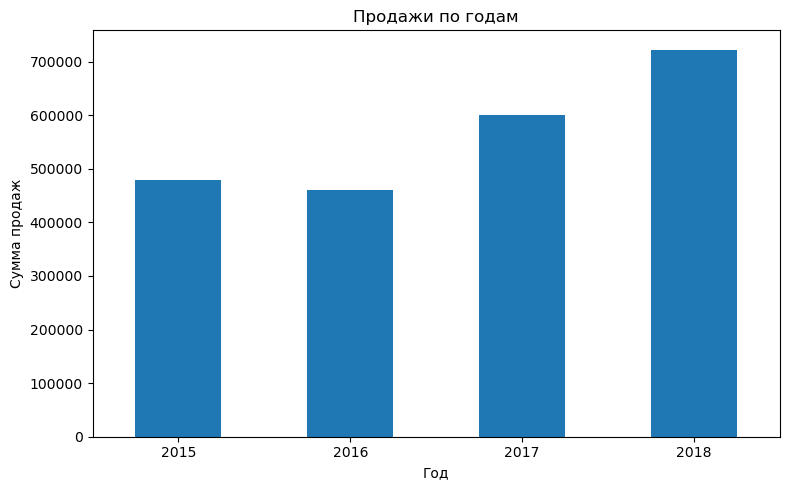

In [23]:
plt.figure(figsize=(8, 5))
sales_by_year.plot(kind="bar")
plt.title("Продажи по годам")
plt.xlabel("Год")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#На графике видно, что максимальный объём продаж наблюдается в 2018 году, а минимальный — в 2016 году. 
#Это может говорить о росте продаж за рассматриваемый период.

In [63]:
#Анализ по месяцам
monthly_sales = df.groupby("order_year_month")["sales"].sum()

monthly_sales

order_year_month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825

In [ ]:
#Анализ динамики продаж по месяцам позволяет увидеть периоды роста и снижения продаж. 
#Пики продаж могут быть связаны с сезонностью, акциями или увеличением спроса в определённые месяцы.

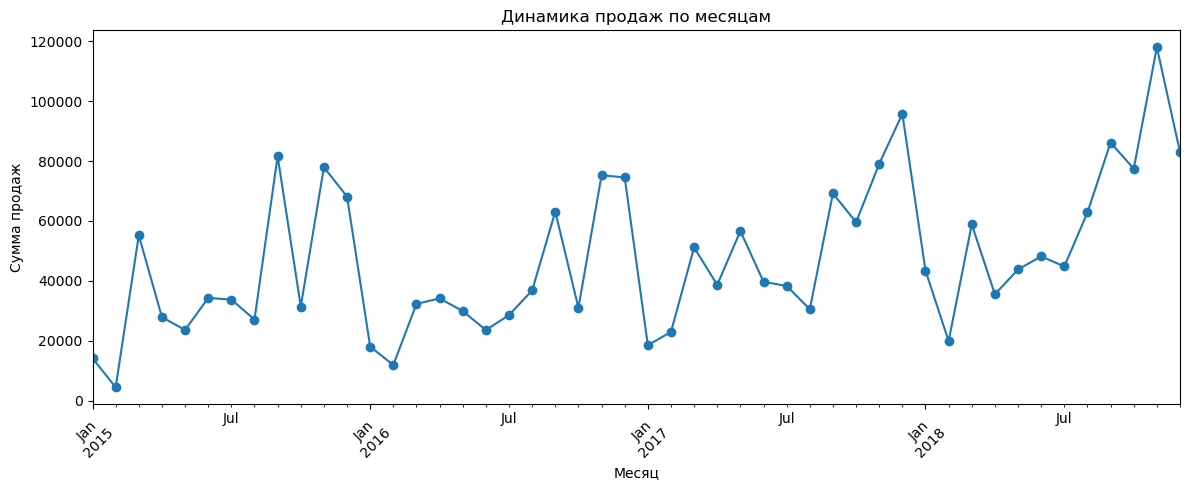

In [30]:
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Динамика продаж по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/monthly_sales.png")
plt.show()

In [ ]:
#На графике видны месяцы с наиболее высокими и низкими продажами. 
#Для точного объяснения причин потребовались бы дополнительные данные о маркетинговых акциях, скидках и сезонности.
#Одной из причин скачков могут быть празднирки. Например: Рождество можно связать с пиками в декабре

In [31]:
#Продажи по категориям
sales_by_category = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_category

category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: sales, dtype: float64

In [ ]:
#Наибольшую сумму продаж приносит категория Technology. 
#Это может быть связано с высоким спросом, высокой стоимостью товаров или большим количеством заказов в этой категории.

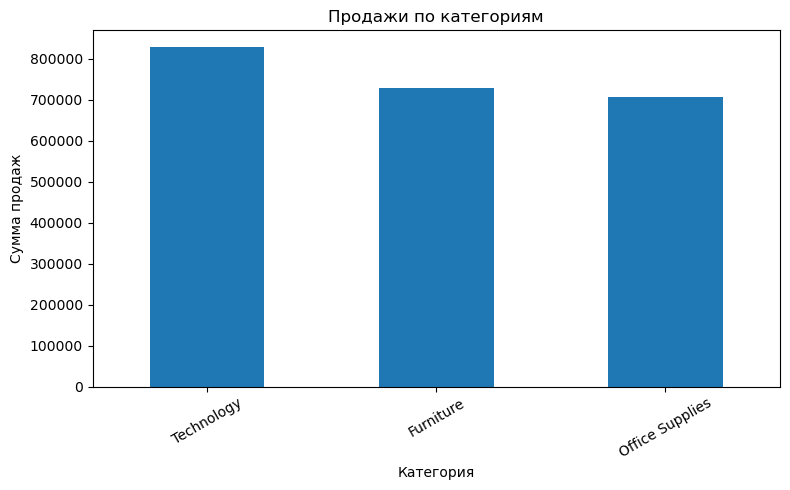

In [32]:
plt.figure(figsize=(8, 5))
sales_by_category.plot(kind="bar")
plt.title("Продажи по категориям")
plt.xlabel("Категория")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("images/sales_by_category.png")
plt.show()

In [35]:
#Продажи по под категориям
sales_by_sub_category = (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_sub_category

sub_category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: sales, dtype: float64

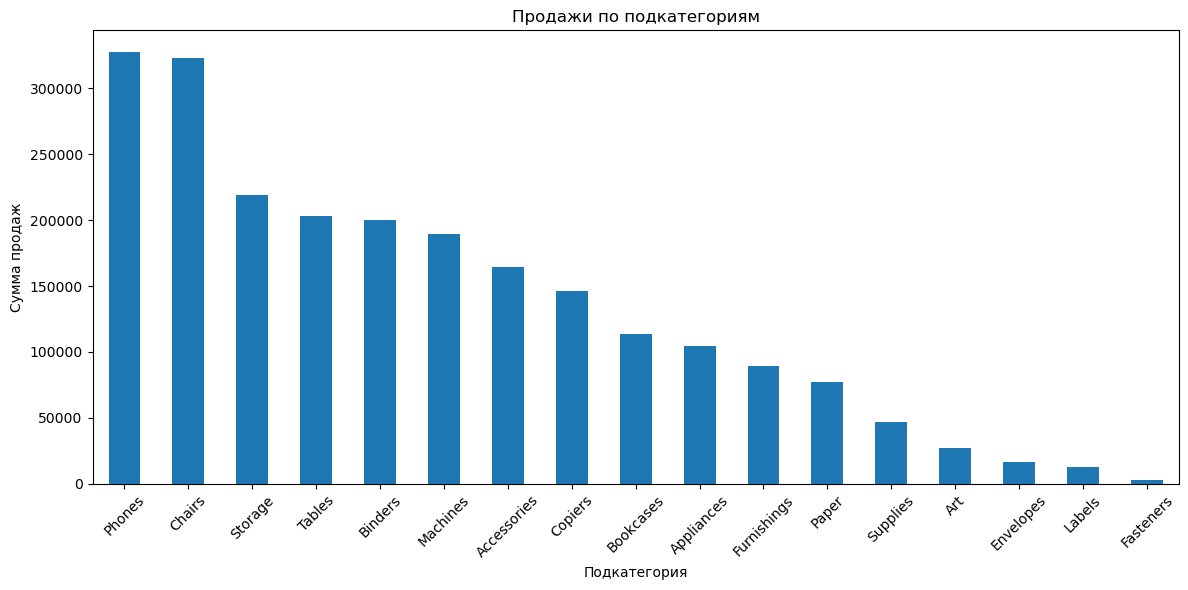

In [36]:
plt.figure(figsize=(12, 6))
sales_by_sub_category.plot(kind="bar")
plt.title("Продажи по подкатегориям")
plt.xlabel("Подкатегория")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
#Анализ подкатегорий позволяет глубже изучить структуру продаж внутри основных товарных категорий. 
#Это помогает понять, какие именно направления дают наибольший вклад в продажи.
#Увдеть интересные явления, как стулья, занимающие второе место, когда вся офисная категория занимает последнее место
#По продажам

In [37]:
#Продажи по регионам
sales_by_region = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

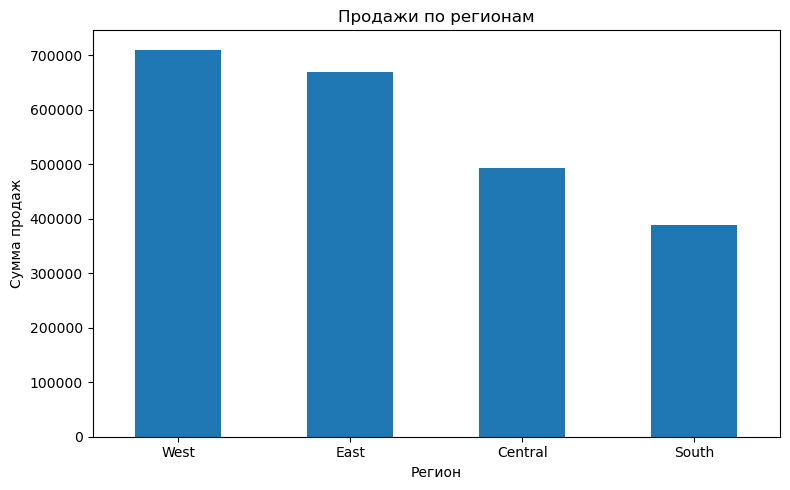

In [38]:
plt.figure(figsize=(8, 5))
sales_by_region.plot(kind="bar")
plt.title("Продажи по регионам")
plt.xlabel("Регион")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/sales_by_region.png")
plt.show()

In [39]:
#Топ-10 штатов по продажам
top_states = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

state
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: sales, dtype: float64

In [ ]:
#Были определены штаты с наибольшей суммой продаж. 
#Такой анализ помогает увидеть, какие территории дают основной вклад в выручку.

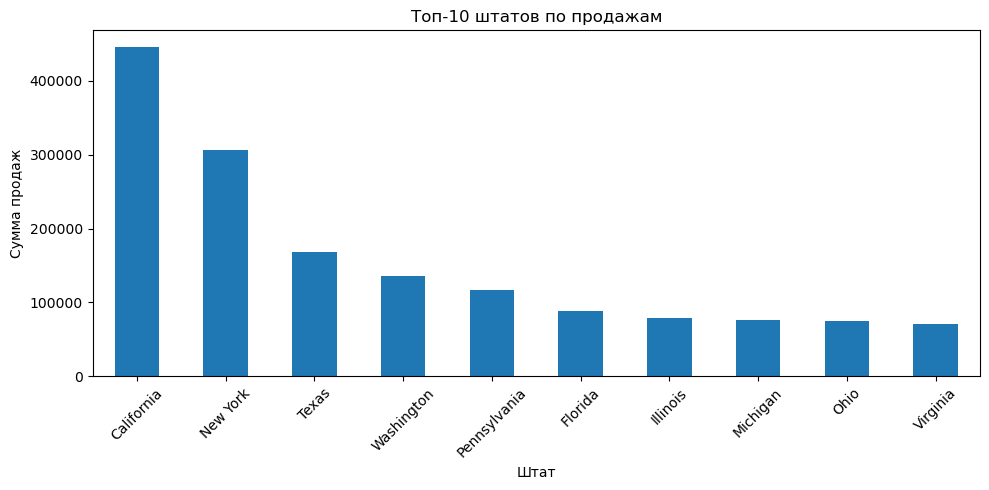

In [40]:
plt.figure(figsize=(10, 5))
top_states.plot(kind="bar")
plt.title("Топ-10 штатов по продажам")
plt.xlabel("Штат")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
#Продажи по сегментам клиентов
sales_by_segment = (
    df.groupby("segment")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: sales, dtype: float64

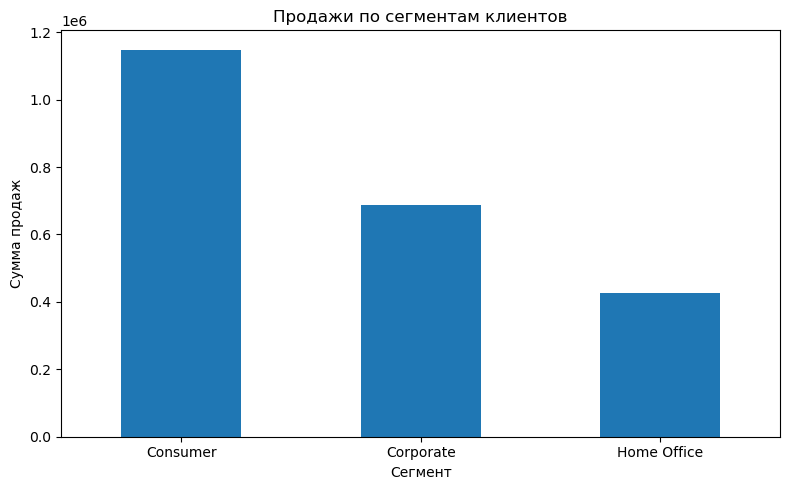

In [42]:
plt.figure(figsize=(8, 5))
sales_by_segment.plot(kind="bar")
plt.title("Продажи по сегментам клиентов")
plt.xlabel("Сегмент")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/sales_by_segment.png")
plt.show()

In [ ]:
Сегментация клиентов помогает понять, на какие группы лучше направить маркетинговую стратегию.

In [43]:
#Продажи по способам доставки
sales_by_ship_mode = (
    df.groupby("ship_mode")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_ship_mode

ship_mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: sales, dtype: float64

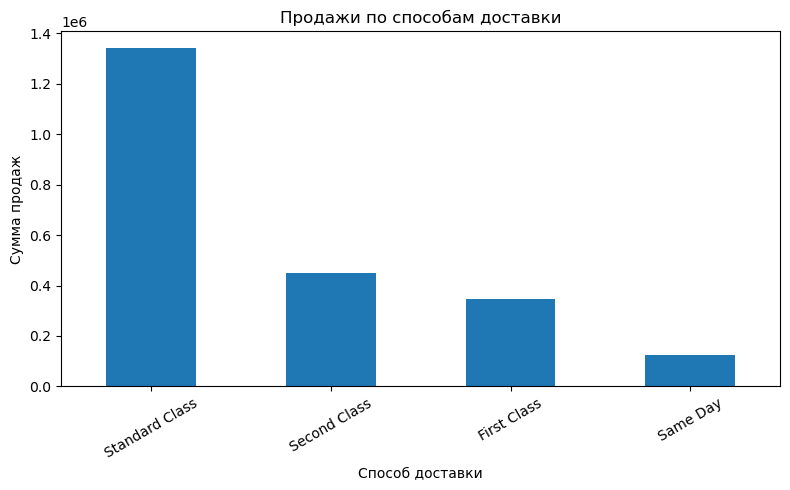

In [44]:
plt.figure(figsize=(8, 5))
sales_by_ship_mode.plot(kind="bar")
plt.title("Продажи по способам доставки")
plt.xlabel("Способ доставки")
plt.ylabel("Сумма продаж")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
orders_by_ship_mode = (
    df.groupby("ship_mode")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

orders_by_ship_mode

ship_mode
Standard Class    2945
Second Class       944
First Class        772
Same Day           261
Name: order_id, dtype: int64

In [46]:
#Топ-10 товаров по продажам
top_products = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

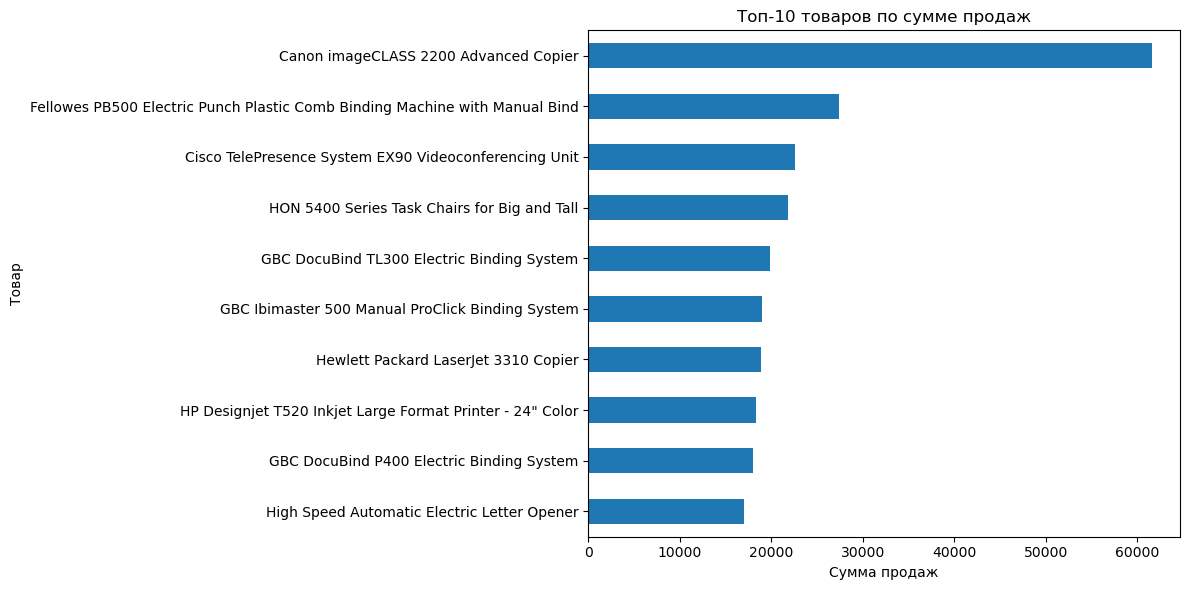

In [47]:
plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Топ-10 товаров по сумме продаж")
plt.xlabel("Сумма продаж")
plt.ylabel("Товар")
plt.tight_layout()
plt.show()

In [ ]:
#Был построен рейтинг товаров по сумме продаж. 
#Это помогает определить товары, которые дают наибольший вклад в общий объём продаж.

In [48]:
#Анализ сроков доставки
df["delivery_days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: delivery_days, dtype: float64

In [49]:
avg_delivery_by_ship_mode = (
    df.groupby("ship_mode")["delivery_days"]
    .mean()
    .sort_values()
)

avg_delivery_by_ship_mode

ship_mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249211
Standard Class    5.008363
Name: delivery_days, dtype: float64

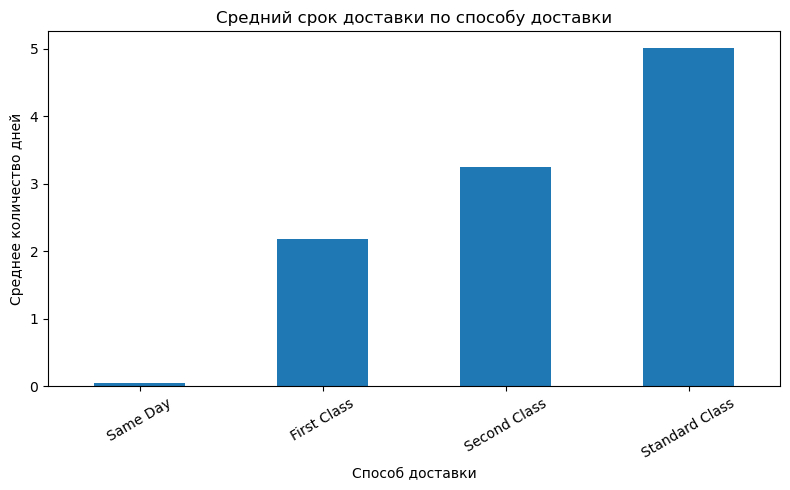

In [50]:
plt.figure(figsize=(8, 5))
avg_delivery_by_ship_mode.plot(kind="bar")
plt.title("Средний срок доставки по способу доставки")
plt.xlabel("Способ доставки")
plt.ylabel("Среднее количество дней")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
#Был рассчитан средний срок доставки для каждого способа доставки. 
#Этот анализ позволяет сравнить, насколько быстро выполняется доставка в зависимости от выбранного режима отправки.

In [51]:
#Проверка аномалий
#Распределение продаж
df["sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: sales, dtype: float64

In [52]:
#самые крупные продажи
df.sort_values("sales", ascending=False).head(10)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub_category,product_name,sales,order_year,order_month,order_year_month,delivery_days
2697,2698,CA-2015-145317,2015-03-18,2015-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,2015,3,2015-03,5
6826,6827,CA-2017-118689,2017-10-02,2017-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,2017,10,2017-10,7
8153,8154,CA-2018-140151,2018-03-23,2018-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,2018,3,2018-03,2
2623,2624,CA-2018-127180,2018-10-22,2018-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,2018,10,2018-10,2
4190,4191,CA-2018-166709,2018-11-17,2018-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,2018,11,2018-11,5
9039,9040,CA-2017-117121,2017-12-17,2017-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,2017,12,2017-12,4
4098,4099,CA-2015-116904,2015-09-23,2015-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,2015,9,2015-09,5
4277,4278,US-2017-107440,2017-04-16,2017-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,2017,4,2017-04,4
8488,8489,CA-2017-158841,2017-02-02,2017-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,2017,2,2017-02,2
6425,6426,CA-2017-143714,2017-05-23,2017-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,2017,5,2017-05,4


In [53]:
#нулевые или отрицательные продажи
df[df["sales"] <= 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub_category,product_name,sales,order_year,order_month,order_year_month,delivery_days


In [65]:
#Была выполнена проверка возможных аномалий: 
#нулевых или отрицательных продаж, слишком крупных значений продаж и отрицательных сроков доставки. 
#Такие значения могут указывать на ошибки в данных или нестандартные бизнес-ситуации.
#В нашем случае их не обнаружено

In [55]:
df_sql = df.copy()
df_sql["order_year_month"] = df_sql["order_year_month"].astype(str)

#Создание базы SQLite
conn = sqlite3.connect("sales.db")
df_sql.to_sql("sales", conn, if_exists="replace", index=False)

9800

In [66]:
#SQL: продажи по категориям
query = """
SELECT 
    category,
    ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY category
ORDER BY total_sales DESC
"""

sql_category_sales = pd.read_sql_query(query, conn)
sql_category_sales

,category,total_sales
0,Technology,827455.87
1,Furniture,728658.58
2,Office Supplies,705422.33


In [57]:
#SQL: продажи по регионам
query = """
SELECT 
    region,
    ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY region
ORDER BY total_sales DESC
"""

sql_region_sales = pd.read_sql_query(query, conn)
sql_region_sales

,region,total_sales
0,West,710219.68
1,East,669518.73
2,Central,492646.91
3,South,389151.46


In [58]:
#SQL: топ-10 товаров
query = """
SELECT 
    product_name,
    ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_sales DESC
LIMIT 10
"""

sql_top_products = pd.read_sql_query(query, conn)
sql_top_products

,product_name,total_sales
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50
6,Hewlett Packard LaserJet 3310 Copier,18839.69
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90
8,GBC DocuBind P400 Electric Binding System,17965.07
9,High Speed Automatic Electric Letter Opener,17030.31


In [59]:
#SQL: средний чек
query = """
SELECT 
    ROUND(AVG(order_sales), 2) AS avg_order_value
FROM (
    SELECT 
        order_id,
        SUM(sales) AS order_sales
    FROM sales
    GROUP BY order_id
) AS orders
"""

sql_avg_order_value = pd.read_sql_query(query, conn)
sql_avg_order_value

,avg_order_value
0,459.48


In [ ]:
## Итоговые выводы
"""
В рамках проекта был проведён исследовательский анализ данных о продажах интернет-магазина.

Основные результаты:

1. Данные были загружены, изучены и проверены на пропуски и дубликаты.
2. Названия столбцов были приведены к удобному формату.
3. Столбцы с датами были преобразованы в формат datetime.
4. Были созданы новые признаки: год, месяц, год-месяц и срок доставки.
5. Были рассчитаны ключевые метрики: общая сумма продаж, количество заказов, количество клиентов, количество товаров и средний чек.
6. Была изучена динамика продаж по годам и месяцам.
7. Были определены категории и подкатегории товаров с наибольшей суммой продаж.
8. Были проанализированы продажи по регионам, штатам и клиентским сегментам.
9. Был выполнен анализ способов доставки и среднего срока доставки.
10. С помощью SQL были повторены основные аналитические расчёты.

Проект показал навыки работы с Python, Pandas, Matplotlib, SQLite, SQL и базовым исследовательским анализом данных.
"""

In [ ]:
## Что можно улучшить
"""
В дальнейшем проект можно расширить:

1. Добавить прогнозирование продаж по месяцам.
2. Построить дашборд в Yandex DataLens, Power BI или Tableau.
3. Провести более глубокий анализ клиентов.
4. Сравнить категории по среднему чеку.
5. Добавить ABC-анализ товаров.
6. Провести анализ сезонности.
7. Добавить когортный анализ, если будут данные о повторных покупках.
"""